In [1]:
#%env JAX_PLATFORM=cpu
%env CUDA_VISIBLE_DEVICES=0
%env XLA_PYTHON_CLIENT_PREALLOCATE=false
%env JAX_ENABLE_X64=True
%env JAX_CHECK_TRACER_LEAKS=true

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

env: CUDA_VISIBLE_DEVICES=0
env: XLA_PYTHON_CLIENT_PREALLOCATE=false
env: JAX_ENABLE_X64=True
env: JAX_CHECK_TRACER_LEAKS=true


In [2]:
from systems import ToyExample, FaultyDSSM, DSSM
from kalman import KalmanFilter
from mpc import MPC, References, Costs as MPCCosts
import equinox as eqx
from jaxtyping import Array, Float, ArrayLike


class SimCosts(eqx.Module):
    y: Float[Array, "y y"]
    u: Float[Array, "u u"]
    x: Float[Array, "x x"]
    z: Float[Array, "z z"]

    def to_mpc(self):
        x = jnp.pad(self.x, ((0, self.z.shape[0]), (0, self.z.shape[1])))
        return MPCCosts(y=self.y, u=self.u, x=x)


sys = ToyExample(
    z_dim=3,
    x_dim=2,
    u_dim=2,
    y_dim=1,
    x_noise_std=0.01,
    y_noise_std=0.01,
)
print(sys.as_dssm())

AugmentedSystem(
    # attributes
    x_dim = 5
    u_dim = 2
    y_dim = 1
)


In [3]:
ref = References(
    y=jnp.ones((30, sys.y_dim)),
    u=jnp.zeros((30, sys.u_dim)),
    x=jnp.zeros((30, sys.as_dssm().x_dim))
)
J = SimCosts(
    y=1.0 * jnp.eye(sys.y_dim),
    u=0.001 * jnp.eye(sys.u_dim),
    x=0.0 * jnp.eye(sys.x_dim),
    z=0.0 * jnp.eye(sys.z_dim),
)
Q = 0.1 * jnp.eye(sys.as_dssm().x_dim)
R = 0.1 * jnp.eye(sys.y_dim)


J_mpc = MPCCosts(y=J.y, u=J.u, x=jnp.pad(J.x, ((0, sys.z_dim), (0, sys.z_dim))))

mpc = MPC(sys.as_dssm(), horizon=10, discount=0.9, ref=ref, J=J_mpc)
kf = KalmanFilter(sys.as_dssm(), Q=Q, R=R)

In [4]:
import flax.linen as nn


class Simulation(nn.Module):
    sys: FaultyDSSM
    J: SimCosts
    ref: References
    mpc_horizon: int
    discount: float
    Q: ArrayLike
    R: ArrayLike

    def setup(self):
        dssm = self.sys.as_dssm()
        self.kf = KalmanFilter(
            sys=dssm,
            Q=jnp.eye(dssm.x_dim) * self.Q,
            R=jnp.eye(dssm.y_dim) * self.R,
        )
        self.mpc = MPC(
            sys=dssm,
            horizon=self.mpc_horizon,
            discount=self.discount,
            ref=self.ref,
            J=self.J.to_mpc(),
        )

    def __call__(self, rng=None):
        rng_step = rng
        x_est = self.kf()
        self.mpc.step(x_est)
        u = self.mpc()
        y = self.sys.step(u, rng=rng_step)
        self.kf.step(u, y)
        return x_est, u, y
    
    @nn.nowrap
    def rollout(self, seed: int):
        def scan_step(var, rng):
            out, var = self.apply(var, rng, mutable=["state"])
            return var, (var, out)

        rng_init, rng_steps = jr.split(jr.key(seed))
        var = self.init(rng_init)
        rng_steps = jr.split(rng_steps, len(self.ref.y)-self.mpc_horizon)
        _, (var, out) = jax.lax.scan(scan_step, var, rng_steps)
        return var, out

sim = Simulation(sys, J, ref, 10, 0.99, Q, R)
var, (x_est, u, y) = sim.rollout(seed=0)

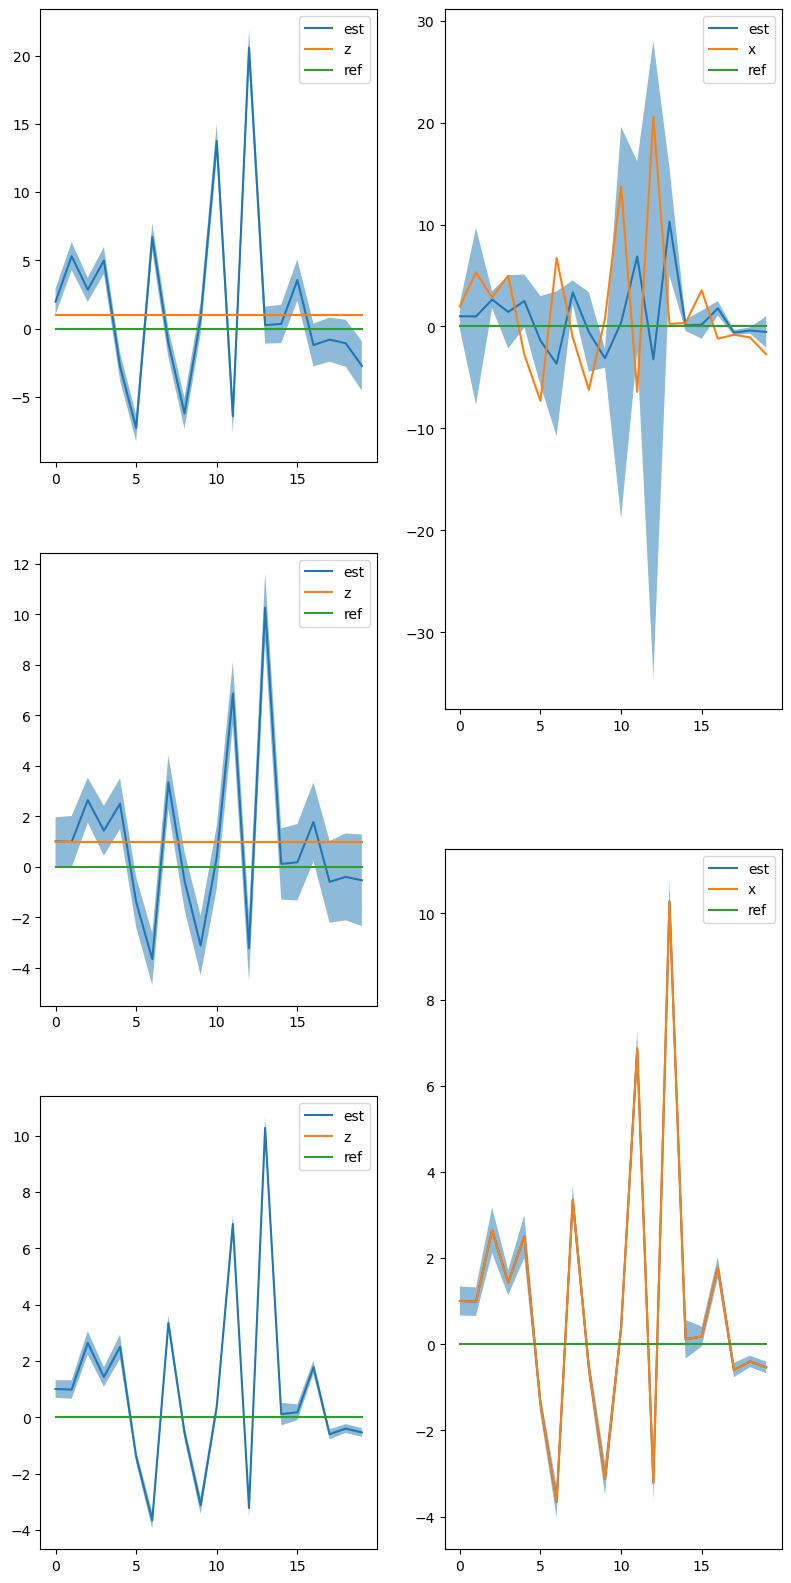

In [15]:
plt.figure(figsize=(20, 20))
for i in range(sys.z_dim):
    plt.subplot(sys.z_dim, 4, 4 * i + 1)
    est = var["state"]["sys"]["x"][:, i]
    cov = var["state"]["kf"]["P"][:, i, i]
    true = var["state"]["sys"]["z"][:, i]
    plt.plot(est, label="est")
    plt.fill_between(jnp.arange(len(est)), est - cov, est + cov, alpha=0.5)
    plt.plot(true, label="z")
    plt.plot(ref.x[:-sim.mpc_horizon, i], label="ref")
    plt.legend()
for i in range(sys.x_dim):
    plt.subplot(sys.x_dim, 4, 4 * i + 2)
    est = var["state"]["sys"]["x"][:, i+sys.z_dim]
    cov = var["state"]["kf"]["P"][:, i+sys.z_dim, i+sys.z_dim]
    true = var["state"]["sys"]["x"][:, i]
    plt.plot(est, label="est")
    plt.fill_between(jnp.arange(len(est)), x_est - cov, x_est + cov, alpha=0.5)
    plt.plot(true, label="x")
    plt.plot(ref.x[:-sim.mpc_horizon, i], label="ref")
    plt.legend()


In [ ]:


sim, out = jax.lax.scan(step, sim, (jnp.arange(100), jr.split(jr.key(0), 100)))
out

NameError: name 'step' is not defined

RecursionError: maximum recursion depth exceeded

In [ ]:
sim.sys.reset()

ToyExample(
  x=f64[2],
  z=f64[4],
  z_dim=4,
  x_dim=2,
  u_dim=2,
  y_dim=2,
  input_coef=1.0,
  flow_coef=0.5,
  output_coef=1.0,
  x_noise_std=0.01,
  y_noise_std=0.01
)